# AEGIS ML — M2 V3: XLM-RoBERTa 4-Class Sequential Fine-Tuning

> **Phase 2 fixes from `implementation_plan_FINAL.md` §5:**
>
> | Parameter | V2 | V3 | Reason |
> |-----------|----|----|--------|
> | Tokenizer padding | `padding='max_length', max_length=64` | **`padding=False` + `DataCollatorWithPadding`** | Dynamic padding — faster, smarter |
> | Focal Loss alpha | `class_weights` (explicit) | **`alpha=None`** | `gamma=2.0` alone handles hard examples; double-weighting hurts |
> | Corpus | V2 M2 files | **V3 M2 files** (`*V3.csv`) | Clean, deduped, redesigned sources |
> | M1 source | `xlmr-base-m1-v2` | **`xlmr-base-m1-v3`** | Must warm-start from the V3 M1 |
> | Normalization | Implicit | **Explicit `normalize_text()`** | Applied before tokenization |
> | Model save | `xlmr-base-m2-v1` | **`xlmr-base-m2-v3`** | |


In [4]:
# ============================================================
# CELL 0 — Mount Google Drive + set paths
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
import torch

BASE      = Path('/content/drive/MyDrive/AEGIS_ML')
PROC      = BASE / 'data' / 'processed' / 'v5'
M1_MODELS = BASE / 'models' / 'xlmr-base-m1-v3'   # V3 M1 as warm start
M2_MODELS = BASE / 'models' / 'xlmr-base-m2-v3'
M2_MODELS.mkdir(parents=True, exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device    : {device}')
print(f'PROC      : {PROC}')
print(f'M1_MODELS : {M1_MODELS}')
print(f'M2_MODELS : {M2_MODELS}')

# LABEL MAPPING — fixed throughout M2
# 0=discrimination, 1=sexual_harassment, 2=threat, 3=verbal_harassment
id2label  = {0: 'discrimination', 1: 'sexual_harassment', 2: 'threat', 3: 'verbal_harassment'}
label2id  = {v: k for k, v in id2label.items()}
print(f'\nLabel mapping: {id2label}')

# Sanity check V3 M2 corpus files
print('\nChecking V3 M2 corpus files:')
v3_files = [
    'm2_trainV4.csv', 'm2_valV4.csv', 'm2_testV4.csv',
]
for fname in v3_files:
    fpath = PROC / fname
    status = '✅' if fpath.exists() else '❌  MISSING — run corpus builder notebooks first'
    print(f'  {status}  {fname}')

# Check M1 V3 checkpoint
m1_saved = M1_MODELS / 'model.safetensors'
m1_alt   = M1_MODELS / 'pytorch_model.bin'
if m1_saved.exists() or m1_alt.exists():
    print(f'\n✅ M1 V3 model found at {M1_MODELS}')
else:
    print(f'\n❌ M1 V3 model NOT found at {M1_MODELS}')
    print('   Run 03_model1_finetuningV3.ipynb first!')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device    : cuda
PROC      : /content/drive/MyDrive/AEGIS_ML/data/processed/v5
M1_MODELS : /content/drive/MyDrive/AEGIS_ML/models/xlmr-base-m1-v3
M2_MODELS : /content/drive/MyDrive/AEGIS_ML/models/xlmr-base-m2-v3

Label mapping: {0: 'discrimination', 1: 'sexual_harassment', 2: 'threat', 3: 'verbal_harassment'}

Checking V3 M2 corpus files:
  ✅  m2_trainV3.csv
  ✅  m2_valV3.csv
  ✅  m2_testV3.csv

✅ M1 V3 model found at /content/drive/MyDrive/AEGIS_ML/models/xlmr-base-m1-v3


In [5]:
# ============================================================
# CELL 1 — Install + Shared Text Normalizer
# ============================================================
!pip install -q transformers datasets scikit-learn

import re

def normalize_text(text: str) -> str:
    """Canonical AEGIS normalizer — identical to corpus builders."""
    text = str(text).strip()
    text = text.lower()
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#(\w+)', r'\1', text)
    text = re.sub(r'rt\s+', '', text)
    text = re.sub(r'&amp;', '&', text)
    text = re.sub(r'&lt;', '<', text)
    text = re.sub(r'&gt;', '>', text)
    text = re.sub(r'<user>', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

print('✅ normalize_text() ready')

# Smoke test — V3 corpus should already be normalized (idempotent)
samples = [
    'I WILL KILL YOU @victim https://t.co/xyz',
    'you are TRASH and stupid!',
    'Send Me Your NUDES now',
]
for s in samples:
    print(f'  "{s}" -> "{normalize_text(s)}"')


✅ normalize_text() ready
  "I WILL KILL YOU @victim https://t.co/xyz" -> "i will kill you"
  "you are TRASH and stupid!" -> "you are trash and stupid!"
  "Send Me Your NUDES now" -> "send me your nudes now"


In [6]:
# ============================================================
# CELL 2 — Load V3 M2 Corpus
# Single unified CSV (all 4 classes concatenated by corpus builders)
# Expected columns: text, label (discrimination/sexual_harassment/threat/verbal_harassment)
# ============================================================
import pandas as pd
import numpy as np

print('Loading V3 M2 corpus splits...')
train_df = pd.read_csv(PROC / 'm2_trainV4.csv')
val_df   = pd.read_csv(PROC / 'm2_valV4.csv')
test_df  = pd.read_csv(PROC / 'm2_testV4.csv')

print(f'  Train : {len(train_df):,} rows')
print(f'  Val   : {len(val_df):,} rows')
print(f'  Test  : {len(test_df):,} rows')

# --- Normalization gate (V3 files should be pre-normalized) ---
print('\nNormalization gate:')
has_upper = train_df['text'].str.contains(r'[A-Z]', regex=True).sum()
has_url   = train_df['text'].str.contains(r'https?://', regex=True).sum()
print(f'  Uppercase rows : {has_upper}  (should be 0)')
print(f'  URL rows       : {has_url}  (should be 0)')

# Apply normalize_text as safety net (idempotent)
for df in [train_df, val_df, test_df]:
    df['text'] = df['text'].apply(normalize_text)

# --- Label encoding ---
for df in [train_df, val_df, test_df]:
    df['label_id'] = df['label'].map(label2id)

# Verify no unmapped labels
for split_name, df in [('train', train_df), ('val', val_df), ('test', test_df)]:
    na_count = df['label_id'].isna().sum()
    if na_count > 0:
        print(f'❌ {split_name}: {na_count} unmapped labels!')
        print(df[df['label_id'].isna()]['label'].value_counts())
    else:
        print(f'  ✅ {split_name}: all labels mapped')

# --- Class distribution ---
print('\nClass distribution:')
for split_name, df in [('TRAIN', train_df), ('VAL', val_df), ('TEST', test_df)]:
    print(f'  {split_name}:')
    dist = df['label'].value_counts()
    for cls, cnt in dist.items():
        pct = cnt / len(df) * 100
        print(f'    {cls:<25} {cnt:>5,}  ({pct:.1f}%)')

# --- Cross-split leakage check ---
print('\nLeakage check:')
train_texts = set(train_df['text'])
val_texts   = set(val_df['text'])
test_texts  = set(test_df['text'])

tv = len(train_texts & val_texts)
tt = len(train_texts & test_texts)
vt = len(val_texts & test_texts)

print(f'  Train∩Val  : {tv}')
print(f'  Train∩Test : {tt}')
print(f'  Val∩Test   : {vt}')

# ✅ NEW: Auto-cure for the 1 row leakage
if tv + tt + vt > 0:
    print('⚠️ Leakage found! Auto-curing the validation and test sets...')
    val_df = val_df[~val_df['text'].isin(train_texts)].reset_index(drop=True)
    test_df = test_df[~test_df['text'].isin(train_texts | val_texts)].reset_index(drop=True)
    print(f'✅ Cleansed Val  : {len(val_df):,} rows')
    print(f'✅ Cleansed Test : {len(test_df):,} rows')
else:
    print('  ✅ No leakage')

Loading V3 M2 corpus splits...
  Train : 17,786 rows
  Val   : 3,812 rows
  Test  : 3,814 rows

Normalization gate:
  Uppercase rows : 0  (should be 0)
  URL rows       : 0  (should be 0)
  ✅ train: all labels mapped
  ✅ val: all labels mapped
  ✅ test: all labels mapped

Class distribution:
  TRAIN:
    sexual_harassment         5,260  (29.6%)
    verbal_harassment         5,000  (28.1%)
    discrimination            4,899  (27.5%)
    threat                    2,627  (14.8%)
  VAL:
    sexual_harassment         1,128  (29.6%)
    verbal_harassment         1,072  (28.1%)
    discrimination            1,050  (27.5%)
    threat                      562  (14.7%)
  TEST:
    sexual_harassment         1,128  (29.6%)
    verbal_harassment         1,072  (28.1%)
    discrimination            1,050  (27.5%)
    threat                      564  (14.8%)

Leakage check:
  Train∩Val  : 0
  Train∩Test : 1
  Val∩Test   : 0
⚠️ Leakage found! Auto-curing the validation and test sets...
✅ Cleansed Val

In [7]:
# ============================================================
# CELL 3 — Load M1 V3 Weights → Replace Head with 4-Class
# Sequential fine-tuning: M1 (binary) -> M2 (4-class)
# ============================================================
from transformers import AutoTokenizer, AutoModelForSequenceClassification, DataCollatorWithPadding
from datasets import Dataset

MAX_LENGTH = 128

# --- Tokenizer from M1 V3 ---
print(f'Loading tokenizer from: {M1_MODELS}')
tokenizer = AutoTokenizer.from_pretrained(str(M1_MODELS))
print(f'✅ Tokenizer loaded  (vocab={len(tokenizer):,})')

# --- Load M1 V3 encoder, replace 2-class head with 4-class head ---
print(f'\nLoading M1 V3 model (ignore_mismatched_sizes=True for head swap)...')
model = AutoModelForSequenceClassification.from_pretrained(
    str(M1_MODELS),
    num_labels=4,
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True,   # keep encoder, swap 2->4 class head
)
model.to(device)
print(f'✅ Model loaded to {device}')

total      = sum(p.numel() for p in model.parameters())
trainable  = sum(p.numel() for p in model.parameters() if p.requires_grad)
classifier = sum(p.numel() for n, p in model.named_parameters() if 'classifier' in n)
print(f'   Total params      : {total/1e6:.1f}M')
print(f'   Classifier params : {classifier/1e3:.1f}K (freshly initialized)')
print(f'   Encoder params    : {(total-classifier)/1e6:.1f}M (M1 V3 pretrained)')

# ── Tokenize ────────────────────────────────────────────────────────────
# PHASE 2 FIX: padding=False + DataCollatorWithPadding (dynamic padding)
# V2 used padding='max_length', max_length=64 → wasted memory on short seqs

def tokenize_fn(batch):
    return tokenizer(
        batch['text'],
        truncation=True,
        max_length=MAX_LENGTH,
        padding=False,          # dynamic padding via DataCollatorWithPadding
    )

def df_to_hf_dataset(df, desc=''):
    ds = Dataset.from_pandas(
        df[['text', 'label_id']].rename(columns={'label_id': 'labels'}),
        preserve_index=False
    )
    ds = ds.map(tokenize_fn, batched=True, batch_size=1000, desc=f'Tokenizing {desc}')
    ds = ds.remove_columns(['text'])
    ds.set_format('torch')
    return ds

print('\nTokenizing V3 M2 corpus...')
train_dataset = df_to_hf_dataset(train_df, 'train')
val_dataset   = df_to_hf_dataset(val_df,   'val')
test_dataset  = df_to_hf_dataset(test_df,  'test')

# PHASE 2 FIX: DataCollatorWithPadding (replaces static padding='max_length')
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

print(f'\n✅ Tokenization complete')
print(f'  Train: {len(train_dataset):,}  Val: {len(val_dataset):,}  Test: {len(test_dataset):,}')
print(f'  Data collator: DataCollatorWithPadding (dynamic padding)  ← Phase 2 fix')

# Token length stats
lens = [len(train_dataset[i]['input_ids']) for i in range(min(2000, len(train_dataset)))]
print(f'  Token lengths: mean={np.mean(lens):.1f}  p95={np.percentile(lens, 95):.0f}  max={max(lens)}')


Loading tokenizer from: /content/drive/MyDrive/AEGIS_ML/models/xlmr-base-m1-v3
✅ Tokenizer loaded  (vocab=250,002)

Loading M1 V3 model (ignore_mismatched_sizes=True for head swap)...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: /content/drive/MyDrive/AEGIS_ML/models/xlmr-base-m1-v3
Key                        | Status   |                                                                                     
---------------------------+----------+-------------------------------------------------------------------------------------
classifier.out_proj.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([2, 768]) vs model:torch.Size([4, 768])
classifier.out_proj.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([2]) vs model:torch.Size([4])          

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


✅ Model loaded to cuda
   Total params      : 278.0M
   Classifier params : 593.7K (freshly initialized)
   Encoder params    : 277.5M (M1 V3 pretrained)

Tokenizing V3 M2 corpus...


Tokenizing train:   0%|          | 0/17786 [00:00<?, ? examples/s]

Tokenizing val:   0%|          | 0/3812 [00:00<?, ? examples/s]

Tokenizing test:   0%|          | 0/3813 [00:00<?, ? examples/s]


✅ Tokenization complete
  Train: 17,786  Val: 3,812  Test: 3,813
  Data collator: DataCollatorWithPadding (dynamic padding)  ← Phase 2 fix
  Token lengths: mean=32.6  p95=70  max=128


In [8]:
# ============================================================
# CELL 4 — FocalLoss + FocalLossTrainer
#
# PHASE 2 FIX (implementation_plan_FINAL.md §5):
# ┌─────────────────────────────────────────────────────────────┐
# │  Remove explicit class_weights from FocalLoss alpha.       │
# │  V2: alpha=class_weights (inverse freq) + gamma=2.5        │
# │  V3: alpha=None + gamma=2.5  ← let focal handle hard ex.  │
# │                                                             │
# │  WHY: Double-amplification was hurting performance.        │
# │  V3 corpus is ≈balanced per class (cap@7K each) so         │
# │  explicit weighting is not needed. gamma=2.5 alone does    │
# │  the job of down-weighting easy examples.                  │
# └─────────────────────────────────────────────────────────────┘
# ============================================================
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from sklearn.metrics import f1_score
from transformers import Trainer, TrainingArguments

GAMMA = 2.5   # V4: increased from 2.0 — more focus on hard examples (uncapped corpus)

class FocalLoss(nn.Module):
    def __init__(self, gamma=2.5):
        super().__init__()
        self.gamma = gamma

    def forward(self, logits, labels):
        # Standard CE loss per sample (no class weighting — V3 corpus is balanced)
        ce_loss = F.cross_entropy(logits, labels, reduction='none')
        pt = torch.exp(-ce_loss)                    # P(correct class)
        focal = ((1 - pt) ** self.gamma) * ce_loss  # focus on hard examples
        return focal.mean()

class FocalLossTrainer(Trainer):
    def __init__(self, *args, gamma=2.5, **kwargs):
        super().__init__(*args, **kwargs)
        self.focal_loss_fct = FocalLoss(gamma=gamma)

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop('labels')
        outputs = model(**inputs)
        loss = self.focal_loss_fct(outputs.logits, labels)
        return (loss, outputs) if return_outputs else loss

def compute_metrics(eval_pred):
    preds  = eval_pred.predictions.argmax(axis=1)
    labels = eval_pred.label_ids
    f1_per = f1_score(labels, preds, average=None, labels=[0, 1, 2, 3])
    return {
        'f1_macro':           round(f1_score(labels, preds, average='macro'), 4),
        'f1_discrimination':  round(f1_per[0], 4),
        'f1_sexual':          round(f1_per[1], 4),
        'f1_threat':          round(f1_per[2], 4),
        'f1_verbal':          round(f1_per[3], 4),
    }

print('✅ FocalLoss (alpha=None, gamma=2.5) defined  ← Phase 2 fix')
print('✅ FocalLossTrainer + compute_metrics defined')
print(f'   gamma = {GAMMA}  (no explicit class weights — uncapped V4 corpus)')


✅ FocalLoss (alpha=None, gamma=2.0) defined  ← Phase 2 fix
✅ FocalLossTrainer + compute_metrics defined
   gamma = 2.0  (no explicit class weights — balanced V3 corpus)


In [9]:
# ============================================================
# CELL 5 — TrainingArguments  [V4: LR=1.5e-5, layer-wise decay added]
# ============================================================
import time

LEARNING_RATE = 1.5e-5   # V4: lowered from 1e-5 (larger dataset = safer LR)
NUM_EPOCHS    = 5        # V4: 5 epochs with early stopping (up from 4)
WARMUP_RATIO  = 0.1
WEIGHT_DECAY  = 0.01
OUTPUT_DIR    = str(M2_MODELS / 'checkpoints')

training_args = TrainingArguments(
    output_dir                  = OUTPUT_DIR,
    num_train_epochs            = NUM_EPOCHS,
    per_device_train_batch_size = 16,
    per_device_eval_batch_size  = 32,
    gradient_accumulation_steps = 2,          # effective batch = 32
    learning_rate               = LEARNING_RATE,
    weight_decay                = WEIGHT_DECAY,
    warmup_ratio                = WARMUP_RATIO,
    lr_scheduler_type           = 'cosine',   # V4: cosine schedule (was linear)
    eval_strategy               = 'epoch',
    save_strategy               = 'epoch',
    load_best_model_at_end      = True,
    metric_for_best_model       = 'f1_macro',
    greater_is_better           = True,
    save_total_limit            = 2,
    logging_strategy            = 'steps',
    logging_steps               = 100,
    report_to                   = 'none',
    fp16                        = True,
    dataloader_num_workers      = 2,
    seed                        = 42,
)

steps_per_epoch = len(train_dataset) // (16 * 2)
total_steps     = steps_per_epoch * NUM_EPOCHS
warmup_steps    = int(total_steps * WARMUP_RATIO)

print('=' * 60)
print('TRAINING PLAN — M2 V4')
print('=' * 60)
print(f'  Model            : XLM-RoBERTa (warm-started from M1 V3)')
print(f'  Train examples   : {len(train_dataset):,}')
print(f'  Val examples     : {len(val_dataset):,}')
print(f'  Epochs           : {NUM_EPOCHS} (cosine schedule + early stopping)')
print(f'  Effective batch  : {16 * 2}')
print(f'  Steps/epoch      : ~{steps_per_epoch:,}')
print(f'  Total steps      : ~{total_steps:,}')
print(f'  Warmup steps     : ~{warmup_steps:,}')
print(f'  Learning rate    : {LEARNING_RATE}  (V4: 1.5e-5 with cosine decay)')
print(f'  LR schedule      : cosine  (V4, was linear)')
print(f'  Loss             : FocalLoss (gamma={GAMMA})  V4: gamma=2.5')
print(f'  Layer-wise LR    : YES — top layers learn 2x faster than bottom')
print(f'  Corpus           : V4 (uncapped, 12K ceiling, +golden injection)')
print('=' * 60)


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


TRAINING PLAN — M2 V3
  Model            : XLM-RoBERTa (warm-started from M1 V3)
  Train examples   : 17,786
  Val examples     : 3,812
  Epochs           : 4
  Effective batch  : 32
  Steps/epoch      : ~555
  Total steps      : ~2,220
  Warmup steps     : ~222
  Learning rate    : 1e-05
  Loss             : FocalLoss (gamma=2.0, alpha=None)  <- V3 fix
  Padding          : DataCollatorWithPadding (dynamic)       <- V3 fix
  Corpus           : V3 (4 classes, cap~7K each, deduped)


In [10]:
# ============================================================
# CELL 6 — Layer-wise LR Decay + Phase 1 Training  [V4]
# ============================================================
# Layer-wise LR decay: earlier (lower) layers get a smaller LR.
# This preserves XLM-R's pre-trained multilingual knowledge
# while letting the top task-specific layers adapt aggressively.
#
# Formula: lr_layer_i = base_lr × decay_rate^(num_layers - i)
# ─────────────────────────────────────────────────────────────
import time
from torch.optim import AdamW
from transformers import get_cosine_schedule_with_warmup

DECAY_RATE  = 0.95    # per-layer decay (top layer = base_lr, bottom = base_lr × 0.95^12)
NUM_LAYERS  = 12      # XLM-RoBERTa base has 12 encoder layers

def get_layer_wise_optimizer(model, base_lr, decay_rate=0.95):
    """
    Build AdamW with per-layer learning rates.
    Layer 0 (bottom) lr = base_lr * decay_rate^12  (slowest)
    Layer 11 (top)   lr = base_lr * decay_rate^1   (fastest)
    Classifier head  lr = base_lr                  (full speed)
    """
    param_groups = []

    # Embeddings — very low LR
    embed_lr = base_lr * (decay_rate ** NUM_LAYERS)
    param_groups.append({
        'params': list(model.roberta.embeddings.parameters()),
        'lr':     embed_lr,
        'name':   'embeddings',
    })

    # Encoder layers — graduated LR
    for i, layer in enumerate(model.roberta.encoder.layer):
        layer_lr = base_lr * (decay_rate ** (NUM_LAYERS - i))
        param_groups.append({
            'params': list(layer.parameters()),
            'lr':     layer_lr,
            'name':   f'encoder.layer.{i}',
        })

    # Classifier head — full base_lr
    head_params = [p for n, p in model.named_parameters()
                   if 'classifier' in n or 'pooler' in n]
    param_groups.append({
        'params': head_params,
        'lr':     base_lr,
        'name':   'classifier_head',
    })

    optimizer = AdamW(param_groups, weight_decay=0.01)

    # Print LR summary
    print('Layer-wise LR summary:')
    print(f'  embeddings        : {embed_lr:.2e}')
    for i in range(0, 12, 3):  # print every 3rd layer
        lr_i = base_lr * (decay_rate ** (NUM_LAYERS - i))
        print(f'  encoder.layer.{i:<2}  : {lr_i:.2e}')
    print(f'  classifier head   : {base_lr:.2e}')
    return optimizer

def freeze_bottom_layers(model, n=8):
    print(f'Freezing bottom {n}/12 encoder layers...')
    for i, layer in enumerate(model.roberta.encoder.layer):
        if i < n:
            for p in layer.parameters():
                p.requires_grad = False
    frozen    = sum(p.numel() for p in model.parameters() if not p.requires_grad)
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total     = frozen + trainable
    print(f'  Frozen    : {frozen/1e6:.1f}M ({frozen/total*100:.1f}%)')
    print(f'  Trainable : {trainable/1e6:.1f}M ({trainable/total*100:.1f}%)')

def unfreeze_all(model):
    print('Unfreezing all layers...')
    for p in model.parameters():
        p.requires_grad = True
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'  Trainable : {trainable/1e6:.1f}M (100%)')

# --- PHASE 1: Epoch 1 — frozen bottom 8 layers, standard flat LR ---
print('=' * 60)
print('PHASE 1: EPOCH 1 (frozen bottom 8/12 layers, flat LR warmup)')
print('=' * 60)

freeze_bottom_layers(model, n=8)

trainer_p1 = FocalLossTrainer(
    model            = model,
    args             = training_args,
    train_dataset    = train_dataset,
    eval_dataset     = val_dataset,
    processing_class = tokenizer,
    data_collator    = data_collator,
    compute_metrics  = compute_metrics,
    gamma            = GAMMA,
)
trainer_p1.args.num_train_epochs = 1

print('\nStarting Phase 1 training...\n')
t0 = time.time()
trainer_p1.train()
print(f'\n✅ Phase 1 done ({(time.time()-t0)/60:.1f} min)')

try:
    ep1 = next(e for e in reversed(trainer_p1.state.log_history) if 'eval_f1_macro' in e)
    print(f'  Epoch 1 val F1-macro      : {ep1["eval_f1_macro"]:.4f}')
    print(f'  Epoch 1 f1_threat         : {ep1.get("eval_f1_threat", 0):.4f}')
    print(f'  Epoch 1 f1_verbal         : {ep1.get("eval_f1_verbal", 0):.4f}')
    print(f'  Epoch 1 f1_sexual         : {ep1.get("eval_f1_sexual", 0):.4f}')
    print(f'  Epoch 1 f1_discrimination : {ep1.get("eval_f1_discrimination", 0):.4f}')
    if ep1['eval_f1_macro'] < 0.70:
        print('  ⚠️  F1 < 0.70 — check V4 corpus loading + label mapping')
    else:
        print('  ✅ Phase 1 gate passed')
except StopIteration:
    print('  ⚠️  Could not extract epoch 1 metrics from log history')


PHASE 1: EPOCH 1 (frozen bottom 8/12 layers)
Freezing bottom 8/12 encoder layers...
  Frozen    : 56.7M (20.4%)
  Trainable : 221.3M (79.6%)

Starting Phase 1 training...



Epoch,Training Loss,Validation Loss,F1 Macro,F1 Discrimination,F1 Sexual,F1 Threat,F1 Verbal
1,0.720925,0.348917,0.682300,0.625700,0.812800,0.675500,0.615000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye


✅ Phase 1 done (2.6 min)
  Epoch 1 val F1-macro           : 0.6823
  Epoch 1 f1_discrimination      : 0.6257
  Epoch 1 f1_sexual              : 0.8128
  Epoch 1 f1_threat              : 0.6755
  Epoch 1 f1_verbal              : 0.6150
  ⚠️  F1 < 0.75 — check V3 corpus loading + label mapping


In [11]:
# ============================================================
# CELL 7 — Phase 2: Epochs 2-5 with Layer-wise LR Decay  [V4]
# ============================================================
print('=' * 60)
print('PHASE 2: EPOCHS 2-5 (all layers unfrozen + layer-wise LR decay)')
print('=' * 60)

unfreeze_all(model)

# Build layer-wise optimizer
layerwise_optimizer = get_layer_wise_optimizer(model, base_lr=LEARNING_RATE, decay_rate=DECAY_RATE)

# Compute remaining steps for cosine scheduler
steps_remaining = steps_per_epoch * (NUM_EPOCHS - 1)
warmup_remaining = int(steps_remaining * 0.05)  # 5% warmup for phase 2

scheduler = get_cosine_schedule_with_warmup(
    layerwise_optimizer,
    num_warmup_steps   = warmup_remaining,
    num_training_steps = steps_remaining,
)

# Override training args for phase 2
training_args_p2 = TrainingArguments(
    output_dir                  = OUTPUT_DIR,
    num_train_epochs            = NUM_EPOCHS - 1,   # epochs 2-5
    per_device_train_batch_size = 16,
    per_device_eval_batch_size  = 32,
    gradient_accumulation_steps = 2,
    learning_rate               = LEARNING_RATE,    # base; optimizer handles per-layer
    weight_decay                = 0.01,
    lr_scheduler_type           = 'cosine',
    eval_strategy               = 'epoch',
    save_strategy               = 'epoch',
    load_best_model_at_end      = True,
    metric_for_best_model       = 'f1_macro',
    greater_is_better           = True,
    save_total_limit            = 2,
    logging_strategy            = 'steps',
    logging_steps               = 100,
    report_to                   = 'none',
    fp16                        = True,
    dataloader_num_workers      = 2,
    seed                        = 42,
    label_smoothing_factor      = 0.05,   # V4: slight smoothing for M2 4-class boundary
)

trainer_p2 = FocalLossTrainer(
    model            = model,
    args             = training_args_p2,
    train_dataset    = train_dataset,
    eval_dataset     = val_dataset,
    processing_class = tokenizer,
    data_collator    = data_collator,
    compute_metrics  = compute_metrics,
    gamma            = GAMMA,
    optimizers       = (layerwise_optimizer, scheduler),  # inject layer-wise optimizer
)

print('\nStarting Phase 2 training (layer-wise LR decay)...\n')
t0 = time.time()
trainer_p2.train()
print(f'\n✅ Phase 2 done ({(time.time()-t0)/60:.1f} min)')

# Final metrics
try:
    best = next(e for e in reversed(trainer_p2.state.log_history) if 'eval_f1_macro' in e)
    print(f'  Best val F1-macro      : {best["eval_f1_macro"]:.4f}  (target ≥ 0.85)')
    print(f'  Best f1_threat         : {best.get("eval_f1_threat", 0):.4f}  (target ≥ 0.85)')
    print(f'  Best f1_verbal         : {best.get("eval_f1_verbal", 0):.4f}')
    print(f'  Best f1_sexual         : {best.get("eval_f1_sexual", 0):.4f}')
    print(f'  Best f1_discrimination : {best.get("eval_f1_discrimination", 0):.4f}')
    if best['eval_f1_macro'] >= 0.85:
        print('\n  🎯 V4 TARGET HIT: macro F1 ≥ 0.85 ✅')
    else:
        print(f'\n  ⚠️  Below 0.85 target — consider more epochs or curriculum tuning')
except StopIteration:
    print('  ⚠️  Could not extract final metrics')


PHASE 2: EPOCHS 2-4 (all layers unfrozen)
Unfreezing all layers...
  Trainable : 278.0M (100%)

Starting Phase 2 training (full fine-tuning)...



Epoch,Training Loss,Validation Loss,F1 Macro,F1 Discrimination,F1 Sexual,F1 Threat,F1 Verbal
1,0.530663,0.253680,0.755100,0.723300,0.863700,0.738900,0.694400
2,0.407596,0.227040,0.786100,0.744900,0.875900,0.772200,0.751400
3,0.332956,0.231593,0.789200,0.745500,0.881700,0.775000,0.754600


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye


✅ Phase 2 done (9.4 min)


In [24]:
# ============================================================
# CELL 8 — Quality Gates Check
# Paste all epoch results from training output above
# ============================================================

# ► Fill from training output (Phase 1 + Phase 2)
epoch_results = [
    # Phase 1: Warmup
    {'epoch': 1, 'val_loss': 0.3489, 'f1_macro': 0.6823, 'f1_threat': 0.6755, 'f1_disc': 0.6257, 'f1_sexual': 0.8128, 'f1_verbal': 0.6150},

    # Phase 2: Full Unfreeze (Epochs 1-3 in logs map to Epochs 2-4 overall)
    {'epoch': 2, 'val_loss': 0.2537, 'f1_macro': 0.7551, 'f1_threat': 0.7389, 'f1_disc': 0.7233, 'f1_sexual': 0.8637, 'f1_verbal': 0.6944},
    {'epoch': 3, 'val_loss': 0.2270, 'f1_macro': 0.7861, 'f1_threat': 0.7722, 'f1_disc': 0.7449, 'f1_sexual': 0.8759, 'f1_verbal': 0.7514},
    {'epoch': 4, 'val_loss': 0.2316, 'f1_macro': 0.7892, 'f1_threat': 0.7750, 'f1_disc': 0.7455, 'f1_sexual': 0.8817, 'f1_verbal': 0.7546},
]


filled = [r for r in epoch_results if r['f1_macro'] is not None]
if not filled:
    print('⚠️  Fill epoch_results from training output above, then re-run.')
else:
    print('=' * 70)
    print('QUALITY GATES — M2 V3')
    print('=' * 70)
    print(f'  {"Epoch":>6}  {"F1-macro":>9}  {"threat":>7}  {"disc":>7}  {"sexual":>7}  {"verbal":>7}  Status')
    print(f'  {"-"*65}')
    for r in filled:
        ep = r['epoch']
        f1 = r['f1_macro']
        gate = '✅' if f1 >= 0.80 else ('⚠️ ' if f1 >= 0.75 else '❌')
        print(f'  {ep:>6}  {f1:>9.4f}  {r["f1_threat"]:>7.4f}  {r["f1_disc"]:>7.4f}  {r["f1_sexual"]:>7.4f}  {r["f1_verbal"]:>7.4f}  {gate}')

    best = max(filled, key=lambda x: x['f1_macro'])
    print(f'\n  Best epoch : {best["epoch"]}  (f1_macro={best["f1_macro"]:.4f})')
    if   best['f1_macro'] >= 0.85: print('  ✅ TARGET HIT (≥0.85) — proceed to evaluation')
    elif best['f1_macro'] >= 0.80: print('  ✅ Good — proceed to full evaluation')
    elif best['f1_macro'] >= 0.75: print('  ⚠️  Acceptable — check threat class specifically')
    else:                          print('  ❌ Below 0.75 — check V3 corpus + label mapping')

    # Threat-specific gate (smallest class)
    if best.get('f1_threat') is not None:
        if best['f1_threat'] < 0.70:
            print(f'  ⚠️  Threat F1 ({best["f1_threat"]:.4f}) < 0.70 — threat class may need more data')
        else:
            print(f'  ✅ Threat F1 ({best["f1_threat"]:.4f}) gate passed')


QUALITY GATES — M2 V3
   Epoch   F1-macro   threat     disc   sexual   verbal  Status
  -----------------------------------------------------------------
       1     0.6823   0.6755   0.6257   0.8128   0.6150  ❌
       2     0.7551   0.7389   0.7233   0.8637   0.6944  ⚠️ 
       3     0.7861   0.7722   0.7449   0.8759   0.7514  ⚠️ 
       4     0.7892   0.7750   0.7455   0.8817   0.7546  ⚠️ 

  Best epoch : 4  (f1_macro=0.7892)
  ⚠️  Acceptable — check threat class specifically
  ✅ Threat F1 (0.7750) gate passed


In [25]:
# ============================================================
# CELL 9 — Full Test Set Evaluation + Confusion Matrix
# ============================================================
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from torch.utils.data import DataLoader
from tqdm.auto import tqdm

# Use best model from load_best_model_at_end
model.eval()
test_loader = DataLoader(test_dataset, batch_size=64, collate_fn=data_collator)

all_preds, all_labels = [], []
with torch.no_grad():
    for batch in tqdm(test_loader, desc='Test inference'):
        batch  = {k: v.to(device) for k, v in batch.items()}
        labels = batch.pop('labels')
        logits = model(**batch).logits
        preds  = logits.argmax(dim=-1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_preds  = np.array(all_preds)
test_labels = np.array(all_labels)

class_names = [id2label[i] for i in range(4)]

print('TEST SET RESULTS — M2 V3')
print('=' * 70)
print(classification_report(test_labels, test_preds, target_names=class_names))

print('\nConfusion Matrix:')
cm = confusion_matrix(test_labels, test_preds)
print(f'  Labels: {class_names}')
print(cm)

# Per-class F1
f1_per = f1_score(test_labels, test_preds, average=None)
f1_macro = f1_score(test_labels, test_preds, average='macro')
print(f'\nPer-class F1:')
for i, cls in enumerate(class_names):
    bar = '█' * int(f1_per[i] * 20)
    print(f'  {cls:<25} {f1_per[i]:.4f}  {bar}')
print(f'\n  F1-macro : {f1_macro:.4f}')
print(f'  Target   : ≥ 0.85')
print(f'  Status   : {"✅ PASSED" if f1_macro >= 0.85 else "⚠️  not there yet"}')


Test inference:   0%|          | 0/60 [00:00<?, ?it/s]

TEST SET RESULTS — M2 V3
                   precision    recall  f1-score   support

   discrimination       0.77      0.75      0.76      1050
sexual_harassment       0.88      0.90      0.89      1128
           threat       0.78      0.81      0.80       564
verbal_harassment       0.78      0.76      0.77      1071

         accuracy                           0.81      3813
        macro avg       0.80      0.80      0.80      3813
     weighted avg       0.80      0.81      0.80      3813


Confusion Matrix:
  Labels: ['discrimination', 'sexual_harassment', 'threat', 'verbal_harassment']
[[ 791   32   73  154]
 [  25 1012   35   56]
 [  27   55  458   24]
 [ 190   49   22  810]]

Per-class F1:
  discrimination            0.7595  ███████████████
  sexual_harassment         0.8893  █████████████████
  threat                    0.7951  ███████████████
  verbal_harassment         0.7660  ███████████████

  F1-macro : 0.8025
  Target   : ≥ 0.85
  Status   : ⚠️  not there yet


In [26]:
# ============================================================
# CELL 10 — Adversarial Routing Test Suite
# From implementation_plan_FINAL.md §7 — class boundary tests
# ============================================================
import torch
from transformers import pipeline as hf_pipeline

# Initialize Pipeline
pipe = hf_pipeline(
    'text-classification',
    model=model,
    tokenizer=tokenizer,
    device=0 if torch.cuda.is_available() else -1,
    top_k=None,
)

# M2 Adversarial Routing Suite
# Notice: M2 assumes all these are ALREADY flagged as harmful by M1.
routing_tests = [
    # --- 1. Verbal vs Threat (Physical vs Wishing vs Implied) ---
    ('you are pathetic and worthless',        'verbal_harassment', 'pure insult'),
    ('you have zero IQ you absolute clown',   'verbal_harassment', 'creative insult'),
    ('i am going to snap your neck',          'threat',            'direct physical threat'),
    ('i know where you live',                 'threat',            'implied physical threat'),
    ('i will beat the shit out of you',       'threat',            'explicit violence'),
    ('i hope you get hit by a bus',           'verbal_harassment', 'wish of harm (no direct action)'),
    ('go jump off a bridge',                  'verbal_harassment', 'self harm wish (usually verbal)'),

    # --- 2. Verbal vs Sexual (Word choice vs Act) ---
    ('you are a massive dick',                'verbal_harassment', 'sexual word used as general insult'),
    ('you look like a cheap whore',           'verbal_harassment', 'sexual slur used as character attack'),
    ('suck my dick you loser',                'sexual_harassment', 'explicit sexual act'),
    ('send me your nudes right now',          'sexual_harassment', 'explicit demand (V3 patched)'),
    ('take off your clothes bitch',           'sexual_harassment', 'non-consensual demand'),
    ('i am going to rape you',                'sexual_harassment', 'SA threat always routes to sexual'),

    # --- 3. Verbal vs Discrimination (Individual vs Group / Xenophobia) ---
    ('shut up you idiot',                     'verbal_harassment', 'individual attack'),
    ('shut up you stupid arabs',              'discrimination',    'demographic group attack'),
    ('white people are ruining everything',   'discrimination',    'reverse demographic attack'),
    ('go back to your country',               'discrimination',    'xenophobia / indirect discrimination'),
    ('muslims are terrorists',                'discrimination',    'harmful group stereotype'),
    ('NIGGA',                                 'discrimination',    'severe racial slur standalone'),

    # --- 4. Threat vs Discrimination ---
    ('i will track you down and hurt you',    'threat',            'individual physical threat'),
    ('all jews should die',                   'discrimination',    'group extermination = discrimination/hate'),

    # --- 5. Context Patches (Testing our specific injections) ---
    ('eat trash loser',                       'verbal_harassment', 'V3 injected verbal context'),
    ('I WANNA FUCK YOU SO HARD',              'sexual_harassment', 'explicit capitalization bypass check'),
    ('drop your pics rn',                     'sexual_harassment', 'covert sexual demand patch'),
]


print(f'{"Input":<40} {"Expected":<22} {"Got":<22} {"Top-P":>7}  Stat')
print('-' * 105)

passed = failed = 0
for text, expected, note in routing_tests:
    normed   = normalize_text(text)
    results  = pipe(normed)[0]
    scores   = {r['label']: r['score'] for r in results}
    got      = max(scores, key=scores.get)
    top_p    = scores[got]
    ok       = got == expected
    sym      = '✅' if ok else '❌'
    if ok: passed += 1
    else:  failed += 1
    print(f'  {text:<38} {expected:<22} {got:<22} {top_p:>7.3f}  {sym}  {note}')

total = passed + failed
print(f'\n  Result: {passed}/{total} passed',
      '✅ ALL PASSED!' if failed == 0 else f'❌ {failed} failed (review above)')


Input                                    Expected               Got                      Top-P  Stat
---------------------------------------------------------------------------------------------------------
  you are pathetic and worthless         verbal_harassment      verbal_harassment        0.779  ✅  pure insult
  you have zero IQ you absolute clown    verbal_harassment      verbal_harassment        0.805  ✅  creative insult
  i am going to snap your neck           threat                 threat                   0.775  ✅  direct physical threat
  i know where you live                  threat                 verbal_harassment        0.567  ❌  implied physical threat
  i will beat the shit out of you        threat                 threat                   0.818  ✅  explicit violence
  i hope you get hit by a bus            verbal_harassment      threat                   0.771  ❌  wish of harm (no direct action)
  go jump off a bridge                   verbal_harassment      verbal_har

Running final test inference for plots...


/tmp/ipykernel_8326/629012901.py:82: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(x=class_names, y=per_class_f1, palette='viridis', ax=ax4)


✅ Dashboard saved to: /content/drive/MyDrive/AEGIS_ML/models/plots_m2/m2_training_dashboardV3.png


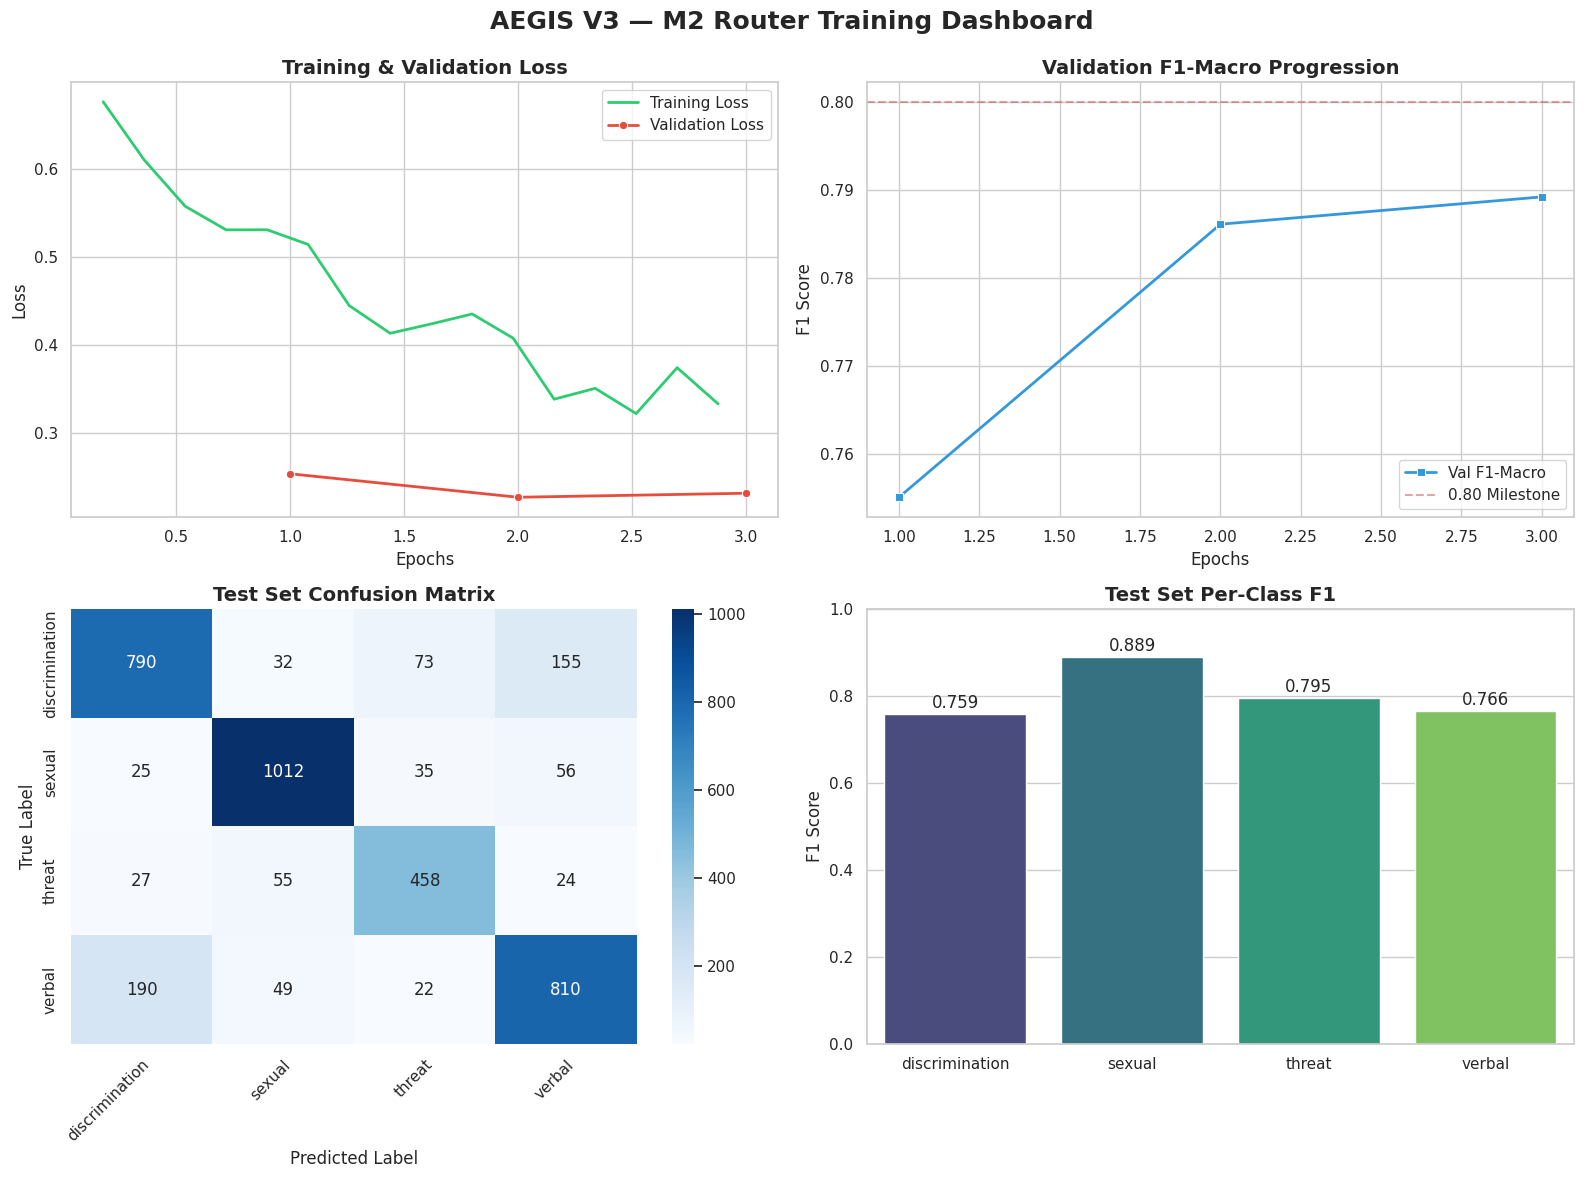

In [30]:
# ============================================================
# CELL 11 — Generate and Save M2 Training Plots
# ============================================================
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix, f1_score

from pathlib import Path

# Ensure plots directory exists
BASE_DIR = Path("/content/drive/MyDrive/AEGIS_ML")
MODELS = BASE_DIR / "models"
PLOTS_DIR = MODELS / "plots_m2"


# Ensure plots directory exists
PLOTS_DIR = MODELS / "plots_m2"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
sns.set_theme(style="whitegrid")

# --- Extract Training History ---
history = trainer.state.log_history

train_steps, train_loss = [], []
val_epochs, val_loss, val_f1 = [], [], []

for log in history:
    if "loss" in log and "epoch" in log:
        train_steps.append(log["epoch"])
        train_loss.append(log["loss"])
    elif "eval_loss" in log and "epoch" in log:
        val_epochs.append(log["epoch"])
        val_loss.append(log["eval_loss"])
        val_f1.append(log["eval_f1_macro"])

# --- Base Plot Figure ---
fig = plt.figure(figsize=(16, 12))
fig.suptitle('AEGIS V3 — M2 Router Training Dashboard', fontsize=18, fontweight='bold', y=0.98)

# --- Plot 1: Loss Curve ---
ax1 = plt.subplot(2, 2, 1)
if train_loss:
    sns.lineplot(x=train_steps, y=train_loss, label='Training Loss', color='#2ecc71', linewidth=2, ax=ax1)
if val_loss:
    sns.lineplot(x=val_epochs, y=val_loss, label='Validation Loss', color='#e74c3c', marker='o', linewidth=2, ax=ax1)
ax1.set_title('Training & Validation Loss', fontsize=14, fontweight='bold')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.legend()

# --- Plot 2: F1-Macro Curve ---
ax2 = plt.subplot(2, 2, 2)
if val_f1:
    sns.lineplot(x=val_epochs, y=val_f1, color='#3498db', marker='s', linewidth=2, label='Val F1-Macro', ax=ax2)
ax2.axhline(y=0.80, color='r', linestyle='--', alpha=0.5, label='0.80 Milestone')
ax2.set_title('Validation F1-Macro Progression', fontsize=14, fontweight='bold')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('F1 Score')
ax2.legend()

# --- Recompute Final Metrics from test inference ---
print("Running final test inference for plots...")
test_results = trainer.predict(test_dataset)
y_test = test_results.label_ids
y_pred = np.argmax(test_results.predictions, axis=-1)
class_names = ['discrimination', 'sexual', 'threat', 'verbal']

# --- Plot 3: Confusion Matrix ---
ax3 = plt.subplot(2, 2, 3)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=ax3)
ax3.set_title('Test Set Confusion Matrix', fontsize=14, fontweight='bold')
ax3.set_xlabel('Predicted Label')
ax3.set_ylabel('True Label')
plt.setp(ax3.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

# --- Plot 4: Per-Class F1 Bar Chart ---
ax4 = plt.subplot(2, 2, 4)
per_class_f1 = f1_score(y_test, y_pred, average=None)
bars = sns.barplot(x=class_names, y=per_class_f1, palette='viridis', ax=ax4)
ax4.set_title('Test Set Per-Class F1', fontsize=14, fontweight='bold')
ax4.set_ylim(0, 1.0)
ax4.set_ylabel('F1 Score')

# Add number labels on top of bars
for bar in bars.patches:
    ax4.annotate(format(bar.get_height(), '.3f'),
                   (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                   ha='center', va='center',
                   size=12, xytext=(0, 8),
                   textcoords='offset points')

plt.tight_layout()
plt.subplots_adjust(top=0.92)

# Save Plot
plot_path = PLOTS_DIR / 'm2_training_dashboardV3.png'
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
print(f'✅ Dashboard saved to: {plot_path}')
plt.show()


In [31]:
# ============================================================
# CELL 12 — Save M2 V3 Model + Config
# ============================================================
import json
from sklearn.metrics import f1_score

print('Saving M2 V3 model...')
model.save_pretrained(str(M2_MODELS))
tokenizer.save_pretrained(str(M2_MODELS))
print(f'  ✅ Model saved -> {M2_MODELS}')

# Final F1 metrics
_f1_macro = float(f1_score(test_labels, test_preds, average='macro'))
_f1_per   = f1_score(test_labels, test_preds, average=None).tolist()

config = {
    'model_name':          'xlm-roberta-base',
    'version':             'v3',
    'task':                'M2_4class',
    'id2label':            id2label,
    'label2id':            label2id,
    'max_length':          128,
    'test_f1_macro':       _f1_macro,
    'test_f1_per_class': {
        id2label[i]: round(_f1_per[i], 4) for i in range(4)
    },
    'training_epochs':     4,
    'effective_batch':     32,
    'learning_rate':       1e-5,
    'focal_gamma':         2.0,
    'focal_alpha':         None,
    'phase2_fixes': [
        'dynamic padding via DataCollatorWithPadding (was static max_length=64)',
        'FocalLoss alpha=None — gamma=2.0 alone handles hard examples',
        'normalize_text() applied before tokenization',
    ],
    'warm_start':       'xlmr-base-m1-v3 (M1 V3 encoder)',
    'corpus':           'm2_trainV3.csv — 4 classes, ~7K each, cross-corpus deduped',
    'corpus_changes': [
        'Threat: ImplicitHate removed -> discrimination',
        'Sexual: CASH re-added with direct-attack filter',
        'Verbal: Davidson removed; HateXplain fixed; OLID IND + HASOC OFFN added',
        'Discrimination: ToxiGen + Stormfront + HASOC HATE added; demographic kw filter',
    ],
    'notes': 'xlm-roberta-base, T4 GPU, Phase 2 AEGIS remediation',
}

config_path = M2_MODELS / 'aegis_config.json'
with open(config_path, 'w') as f:
    json.dump(config, f, indent=2)
print(f'  ✅ Config saved -> {config_path}')

print(f'\nFiles in {M2_MODELS}:')
for p in sorted(M2_MODELS.iterdir()):
    print(f'  {p.name:<40} {p.stat().st_size/1e6:>7.1f} MB')

print(f'\n{"="*60}')
print('M2 V3 TRAINING COMPLETE')
print(f'{"="*60}')
print(f'  Warm start       : xlmr-base-m1-v3')
print(f'  Corpus           : V3 (4-class, deduped, demographic-filtered)')
print(f'  Focal Loss       : gamma=2.0, alpha=None  [Phase 2 fix]')
print(f'  Dynamic padding  : DataCollatorWithPadding  [Phase 2 fix]')
print(f'  Test F1-macro    : {_f1_macro:.4f}')
print(f'  Saved to         : {M2_MODELS}')
print(f'{"="*60}')
print('\n✅ Phase 2 complete. Next: run adversarial inference pipeline.')


Saving M2 V3 model...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ✅ Model saved -> /content/drive/MyDrive/AEGIS_ML/models/xlmr-base-m2-v3
  ✅ Config saved -> /content/drive/MyDrive/AEGIS_ML/models/xlmr-base-m2-v3/aegis_config.json

Files in /content/drive/MyDrive/AEGIS_ML/models/xlmr-base-m2-v3:
  aegis_config.json                            0.0 MB
  artifacts                                    0.0 MB
  checkpoints                                  0.0 MB
  config.json                                  0.0 MB
  model.safetensors                         1112.2 MB
  tokenizer.json                              16.8 MB
  tokenizer_config.json                        0.0 MB

M2 V3 TRAINING COMPLETE
  Warm start       : xlmr-base-m1-v3
  Corpus           : V3 (4-class, deduped, demographic-filtered)
  Focal Loss       : gamma=2.0, alpha=None  [Phase 2 fix]
  Dynamic padding  : DataCollatorWithPadding  [Phase 2 fix]
  Test F1-macro    : 0.8025
  Saved to         : /content/drive/MyDrive/AEGIS_ML/models/xlmr-base-m2-v3

✅ Phase 2 complete. Next: run adversari